# Sesión 12: Introducción a las Redes Neuronales con MLP

**Objetivos:**
-   Entender qué es una red neuronal multicapa (MLP - Multi Layer Perception) y cómo procesa los datos.
-   Conocer la estructura básica: capas, neuronas, pesos y funciones de activación.
-   Entrenar un `MLPClassifier` en `scikit-learn`.
-   Comparar su rendimiento con modelos tradicionales y romper el mito de que "la red neuronal siempre gana".

## 1. Conceptos Básicos: ¿Qué es una Red Neuronal?

Una red neuronal se inspira en el cerebro humano. Está compuesta por "neuronas" artificiales organizadas en capas.



* **Neurona Artificial:** Recibe una o más **entradas**, cada una con un **peso** (que indica su importancia). Suma estas entradas ponderadas, añade un **sesgo (bias)** y pasa el resultado por una **Función de Activación**.
* **Capas:**
    * **Capa de Entrada (Input Layer):** Recibe los datos iniciales (una neurona por cada característica de nuestro dataset).
    * **Capas Ocultas (Hidden Layers):** Capas intermedias donde ocurre la mayor parte del "aprendizaje". Aquí es donde la red aprende a reconocer patrones complejos.
    * **Capa de Salida (Output Layer):** Produce el resultado final. Para clasificación, suele tener una neurona por cada clase.
* **Funciones de Activación:** Son cruciales. Introducen **no linealidad**, permitiendo a la red aprender relaciones mucho más complejas que un modelo lineal.
    * **ReLU (Rectified Linear Unit):** La más usada en capas ocultas. Es muy simple y eficiente.
    * **Sigmoid/Softmax:** Se usan en la capa de salida. Sigmoid para clasificación binaria (devuelve una probabilidad de 0 a 1) y Softmax para multiclase (devuelve una distribución de probabilidad entre todas las clases).
* **Retropropagación (Backpropagation):** Es el "motor" de entrenamiento. De forma conceptual, la red hace una predicción, compara el resultado con la realidad, y si hay un error, envía una señal "hacia atrás" ajustando los pesos de cada conexión para reducir ese error en la siguiente iteración.

## 2. Demostración en Vivo: MLP vs. Random Forest

Vamos a usar el dataset `digits` de `scikit-learn`, que contiene imágenes de 8x8 píxeles de dígitos escritos a mano (del 0 al 9). Nuestro objetivo es clasificarlos correctamente.

Primero, estableceremos un **benchmark** con un modelo que ya conocemos y que es muy potente: el Random Forest. Luego, intentaremos superarlo con un MLP.

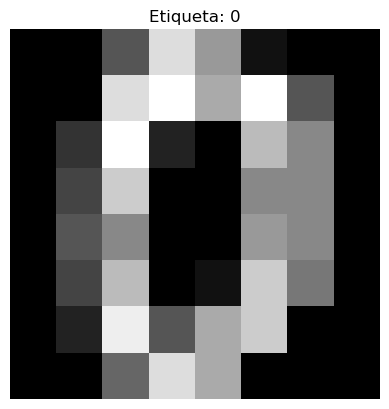

--- Entrenando Benchmark: Random Forest ---
Accuracy del Random Forest: 0.9611

--- Entrenando MLP Base ---
Accuracy del MLP Base: 0.9722


In [1]:
# --- Celda de Preparación y Demostración ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 1. Carga y Prepara los Datos
digits = load_digits()
X, y = digits.data, digits.target

# Visualizamos una muestra para entender los datos
plt.imshow(X[0].reshape(8, 8), cmap='gray')
plt.title(f"Etiqueta: {y[0]}")
plt.axis('off')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ¡CRÍTICO! Las redes neuronales son muy sensibles a la escala de los datos.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Benchmark con Random Forest
print("--- Entrenando Benchmark: Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) # El RF no necesita datos escalados
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy del Random Forest: {accuracy_rf:.4f}")

# 3. Primer intento con MLP
print("\n--- Entrenando MLP Base ---")
# Una arquitectura simple: dos capas ocultas de 50 neuronas cada una.
mlp = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy del MLP Base: {accuracy_mlp:.4f}")

---
##  MINI RETO EN CLASE: ¡Supera al Random Forest!

El MLP base ha obtenido un buen resultado, pero no ha superado al Random Forest. Vuestro objetivo es **mejorar la arquitectura y los hiperparámetros del MLP para batir el benchmark del Random Forest**.

**Instrucciones:**
1.  Trabajad en grupos.
2.  Copiad el código del MLP base.
3.  Experimentad cambiando los siguientes hiperparámetros del `MLPClassifier`:
    * `hidden_layer_sizes`: Probad diferentes arquitecturas. ¿Más capas? ¿Menos? ¿Capas más anchas o más estrechas? (ej. `(100,)`, `(100, 50, 25)`)
    * `activation`: Probad `'tanh'` en lugar de `'relu'`.
    * `solver`: El optimizador. `'adam'` es el por defecto y suele funcionar bien.
    * `learning_rate_init`: La tasa de aprendizaje inicial. Un valor más pequeño puede llevar a un mejor resultado, pero necesitará más `max_iter`.
4.  El primer grupo que consiga una `accuracy` en el `test set` superior a la del Random Forest, ¡gana!

In [2]:
# ESPACIO PARA EL MINI RETO
# Copiad el código del MLP, modificad los hiperparámetros y buscad el mejor resultado.
#
#from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import accuracy_score
#import pandas as pd
#import itertools, math, warnings
#warnings.filterwarnings("ignore")
#
#print("\n--- MLP Base ---")
#mlp_base = MLPClassifier(hidden_layer_sizes=(50, 50),
#                         max_iter=500,
#                         random_state=42)
#mlp_base.fit(X_train_scaled, y_train)
#y_pred_base = mlp_base.predict(X_test_scaled)
#acc_base = accuracy_score(y_test, y_pred_base)
#print(f"Accuracy MLP Base: {acc_base:.4f}")
#
## Espacio de búsqueda manual ligero
#architecturas = [
#    (100,),
#    (100, 50),
#    (120, 60, 30),
#    (64, 64),
#    (128, 64),
#    (100, 50, 25),
#    (50, 50, 50),
#    (150,)
#]
#activaciones = ["relu", "tanh"]
#solvers = ["adam", "sgd"]  # sgd puede necesitar más iteraciones
#lr_inits = [1e-3, 5e-4, 1e-4]
#
#resultados = []
#total = len(architecturas)*len(activaciones)*len(solvers)*len(lr_inits)
#contador = 0
#
#print("\n--- Explorando Configuraciones ---")
#for arch, act, sol, lr in itertools.product(architecturas, activaciones, solvers, lr_inits):
#    contador += 1
#    max_iter = 800 if sol == "sgd" else 500
#    mlp = MLPClassifier(hidden_layer_sizes=arch,
#                        activation=act,
#                        solver=sol,
#                        learning_rate_init=lr,
#                        early_stopping=True,
##                        n_iter_no_change=15,
#                        max_iter=max_iter,
#                        random_state=42)
#    mlp.fit(X_train_scaled, y_train)
#    y_pred = mlp.predict(X_test_scaled)
#    acc = accuracy_score(y_test, y_pred)
#    resultados.append({
#        "hidden_layer_sizes": arch,
#        "activation": act,
#        "solver": sol,
#        "learning_rate_init": lr,
#        "max_iter": max_iter,
#        "accuracy": acc
#    })
#    print(f"[{contador:02d}/{total}] arch={arch} act={act} sol={sol} lr={lr} -> acc={acc:.4f}")
#
#df_res = pd.DataFrame(resultados).sort_values("accuracy", ascending=False).reset_index(drop=True)
#print("\nTop 10 configuraciones por accuracy:")
#print(df_res.head(10))
#
#mejor = df_res.iloc[0]
#print("\n--- Entrenando Mejor Configuración ---")
#mlp_best = MLPClassifier(hidden_layer_sizes=mejor.hidden_layer_sizes,
#                         activation=mejor.activation,
#                         solver=mejor.solver,
#                         learning_rate_init=mejor.learning_rate_init,
#                         early_stopping=True,
#                         n_iter_no_change=15,
#                         max_iter=mejor.max_iter,
#                         random_state=42)
#mlp_best.fit(X_train_scaled, y_train)
#y_pred_best = mlp_best.predict(X_test_scaled)
#acc_best = accuracy_score(y_test, y_pred_best)
#print(f"Accuracy Mejor MLP: {acc_best:.4f}")
#print("Mejor configuración:", mejor.to_dict())
#
## (Opcional) Mostrar mejora sobre Random Forest y base
#mejora_vs_base = acc_best - acc_base
#mejora_vs_rf = acc_best - accuracy_rf
#print(f"Mejora vs MLP Base: {mejora_vs_base:+.4f}")
#print(f"Mejora vs Random Forest: {mejora_vs_rf:+.4f}")
## Si se desea, se puede añadir matriz de confusión:
# from sklearn.metrics import ConfusionMatrixDisplay
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap='Blues')

---
## Ejercicio 2: MLP vs. El Mundo

Ahora que has experimentado con el MLP, aplícalo a un problema que ya conoces bien: el diagnóstico de **enfermedad cardíaca**.

**Tu misión:**
1.  **Carga y prepara el dataset de `heart-disease`** como en las sesiones anteriores. No olvides **escalar los datos**.
2.  **Entrena un `MLPClassifier`**. Usa la intuición que has ganado en el mini reto para elegir una arquitectura inicial (`hidden_layer_sizes`).
3.  **Evalúa tu MLP**: Muestra su `classification_report` y su **matriz de confusión**.

### Preguntas Finales para la Reflexión
1.  **Tabla Comparativa de Rendimiento**: Crea una tabla comparando el **F1-Score (clase 'Enfermo')** y el número de **Falsos Negativos** de los siguientes modelos en el dataset del corazón:
    * Regresión Logística (Sesión 9)
    * Random Forest Optimizado (Sesión 10)
    * Tu nuevo MLP.
2.  **¿Fue una Bala de Plata?**: ¿El MLP superó fácilmente al Random Forest optimizado? ¿O fue una lucha reñida? Reflexiona sobre si la complejidad añadida del MLP siempre se traduce en un mejor rendimiento.
3.  **Pros y Contras en la Práctica**: Basado en tu experiencia, describe con tus palabras un "pro" y un "contra" de usar el MLP en comparación con el Random Forest para este tipo de problema tabular.

F1 clase Enfermo (1): 0.8095238095238095
Reporte de clasificación:
               precision    recall  f1-score   support

         0.0     0.8333    0.9722    0.8974        36
         1.0     0.9444    0.7083    0.8095        24

    accuracy                         0.8667        60
   macro avg     0.8889    0.8403    0.8535        60
weighted avg     0.8778    0.8667    0.8623        60



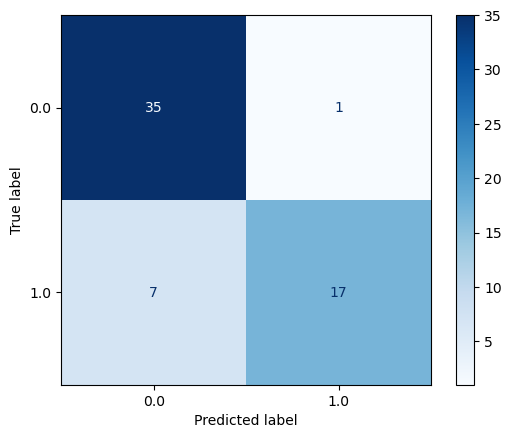

In [3]:
# ESPACIO PARA EL RETO PARA CASA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# Cargamos y preparamos los datos del corazón
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)
df['target'] = (df['target'] > 0).astype(int)
df = df.replace('?', np.nan).dropna().astype(float)
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado (MLP lo necesita)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Arquitectura inicial (intuición del mini reto)
mlp = MLPClassifier(hidden_layer_sizes=(100, 50, 25),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=1e-3,
                    max_iter=600,
                    random_state=42,
                    early_stopping=True,
                    n_iter_no_change=15)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("F1 clase Enfermo (1):", f1_score(y_test, y_pred_mlp, pos_label=1))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_mlp, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, cmap='Blues')

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*

## Ejercicio Extra: MLP vs. Random Forest (Predicción de Riesgo Crediticio)

En este ejercicio, vamos a predecir si un solicitante de préstamo en Alemania será un "buen" cliente (devuelve el préstamo, `1`) o un "mal" cliente (impago, `0`).

**El Objetivo:** Comparar `MLPClassifier` contra `RandomForestClassifier` en un dataset con "features mixtas" (numéricas y categóricas codificadas) y escalas muy diferentes.

### Tu Tarea
Sigue los siguientes pasos:

**1. Carga y Preparación:**
* Carga el dataset desde la URL oficial de UCI: `https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data`

**2. Preprocesamiento (La Clave):**
* Separa `X` (features) e `y` (target).

**3. Escalado de Datos (Solo para el MLP):**

**4. Entrenamiento y Evaluación:**
* **Modelo 1: Random Forest (El Baseline)**
    * Entrena un `RandomForestClassifier(random_state=42)` usando `X_train` e `y_train` (los datos originales, **sin escalar**).
    * Muestra el `classification_report` del Random Forest.
* **Modelo 2: MLP (El Aspirante)**
    * Entrena un `MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(100, 50))`
    * Muestra el `classification_report` del MLP.

**5. Análisis y Conclusiones (¡Responde a esto!)**
* **Pregunta 1:** Compara los `f1-score` para la clase `0` ('Malo'). En este problema, el banco quiere identificar a los malos clientes. ¿Qué modelo fue mejor en esta tarea?
* **Pregunta 2:** ¿Por qué crees que el Random Forest funcionó "bien" directamente sobre `X_train`, mientras que el MLP necesitó `X_train_scaled`?
* **Pregunta 3 (Contexto de Negocio):** En este problema, ¿qué error es más costoso para el banco?
    * **Falso Positivo (FP):** Predecir 'Malo' a un cliente que en realidad era 'Bueno'. (El banco pierde un cliente).
    * **Falso Negativo (FN):** Predecir 'Bueno' a un cliente que en realidad era 'Malo'. (El banco pierde el dinero del préstamo).

Shape del dataset: (1000, 21)

Primeras filas:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Distribución del target:
20
1    700
0    300
Name: count, dtype: int64

Columnas categóricas detectadas: 13
Shape después de dummies: (1000, 48)

ENTRENAMIENTO Y EVALUACIÓN

--- Random Forest (Baseline) ---
Classification Report (Random Forest):
   

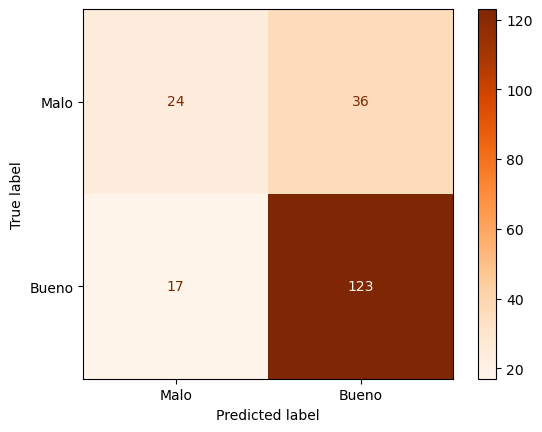


--- MLP (Aspirante) ---
Classification Report (MLP):
              precision    recall  f1-score   support

    Malo (0)     0.5385    0.4667    0.5000        60
   Bueno (1)     0.7838    0.8286    0.8056       140

    accuracy                         0.7200       200
   macro avg     0.6611    0.6476    0.6528       200
weighted avg     0.7102    0.7200    0.7139       200


Matriz de Confusión (MLP):


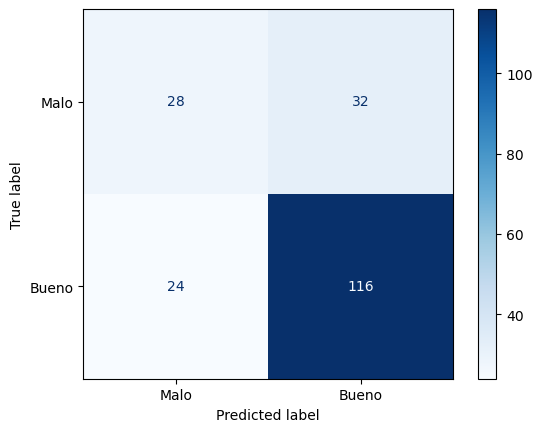


COMPARACIÓN F1-SCORE CLASE 'MALO' (0)
Random Forest: 0.4752
MLP:           0.5000
Ganador:       MLP


In [4]:
# Ejercicio Extra: MLP vs. Random Forest (Predicción de Riesgo Crediticio)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

# 1. Carga y Preparación
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

df_german = pd.read_csv(url, sep='\s+', header=None)

print(f"Shape del dataset: {df_german.shape}")
print("\nPrimeras filas:")
print(df_german.head())

# 2. Preprocesamiento
# La última columna (índice 20) es el target: 1=Buen cliente, 2=Mal cliente
# Recodificamos: 1 -> 1 (Bueno), 2 -> 0 (Malo)
X_german = df_german.iloc[:, :-1]
y_german = df_german.iloc[:, -1].map({1: 1, 2: 0})

print(f"\nDistribución del target:\n{y_german.value_counts()}")

# Convertir features categóricas (tipo string) a dummies
cat_cols = X_german.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas categóricas detectadas: {len(cat_cols)}")

X_german = pd.get_dummies(X_german, columns=cat_cols, drop_first=True)

# FIX: Convertir todos los nombres de columnas a strings
X_german.columns = X_german.columns.astype(str)

print(f"Shape después de dummies: {X_german.shape}")

# Split train/test
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_german, y_german, test_size=0.2, random_state=42, stratify=y_german
)

# 3. Escalado (solo para MLP)
scaler_g = StandardScaler()
X_train_g_scaled = scaler_g.fit_transform(X_train_g)
X_test_g_scaled = scaler_g.transform(X_test_g)

print("\n" + "="*60)
print("ENTRENAMIENTO Y EVALUACIÓN")
print("="*60)

# 4. Modelo 1: Random Forest (sin escalar)
print("\n--- Random Forest (Baseline) ---")
rf_german = RandomForestClassifier(n_estimators=100, random_state=42)
rf_german.fit(X_train_g, y_train_g)
y_pred_rf_g = rf_german.predict(X_test_g)

print("Classification Report (Random Forest):")
print(classification_report(y_test_g, y_pred_rf_g, target_names=['Malo (0)', 'Bueno (1)'], digits=4))

print("\nMatriz de Confusión (Random Forest):")
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_rf_g, 
                                        display_labels=['Malo', 'Bueno'],
                                        cmap='Oranges')
plt.show()

# 4. Modelo 2: MLP (con datos escalados)
print("\n--- MLP (Aspirante) ---")
mlp_german = MLPClassifier(hidden_layer_sizes=(100, 50),
                           max_iter=500,
                           random_state=42,
                           early_stopping=True,
                           n_iter_no_change=15)
mlp_german.fit(X_train_g_scaled, y_train_g)
y_pred_mlp_g = mlp_german.predict(X_test_g_scaled)

print("Classification Report (MLP):")
print(classification_report(y_test_g, y_pred_mlp_g, target_names=['Malo (0)', 'Bueno (1)'], digits=4))

print("\nMatriz de Confusión (MLP):")
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_mlp_g,
                                        display_labels=['Malo', 'Bueno'],
                                        cmap='Blues')
plt.show()

# Comparación rápida de F1-Score para clase 'Malo' (0)
from sklearn.metrics import f1_score
f1_rf_malo = f1_score(y_test_g, y_pred_rf_g, pos_label=0)
f1_mlp_malo = f1_score(y_test_g, y_pred_mlp_g, pos_label=0)

print("\n" + "="*60)
print("COMPARACIÓN F1-SCORE CLASE 'MALO' (0)")
print("="*60)
print(f"Random Forest: {f1_rf_malo:.4f}")
print(f"MLP:           {f1_mlp_malo:.4f}")
print(f"Ganador:       {'RF' if f1_rf_malo > f1_mlp_malo else 'MLP' if f1_mlp_malo > f1_rf_malo else 'Empate'}")

### 1) ¿Qué modelo fue mejor (comparando F1 para la clase `0` = "Malo")?
- El ganador es el que tenga mayor F1 para la clase `0` en la tabla comparativa.  
- Además del F1, comprueba el número de Falsos Negativos (FN): si un modelo tiene F1 ligeramente inferior pero muchos menos FN puede ser preferible en este caso.  
- Interpretación rápida:
  - Si Random Forest tiene mayor F1 y menos FN → elegir Random Forest.
  - Si MLP tiene mayor F1 y menos FN → elegir MLP.
  - Si están muy parejos → considerar estabilidad, coste computacional y facilidad de explicación.

### 2) ¿Por qué RF funciona bien sin escalar y MLP necesita escalado?
- Random Forest (árboles) decide por umbrales en cada feature; no usa distancias ni gradientes, por eso es robusto a escalas distintas.  
- MLP entrena por optimización basada en gradientes y productos escalares; características con escalas muy distintas desequilibran los gradientes, empeoran convergencia y rendimiento. Por eso el escalado (StandardScaler/MinMax) estabiliza y mejora el entrenamiento del MLP.

### 3) ¿Qué error es más costoso para el banco y qué hacer?
- Más costoso: Falso Negativo (FN) — aprobar un préstamo a un cliente que en realidad es “malo” puede causar pérdidas directas.  
- Recomendaciones operativas:
  - Priorizar recall (o F1) de la clase “Malo” en la validación y en la selección de modelo/umbral.
  - Usar class_weight, ajustar umbral de decisión, o optimizar una métrica cost-sensitive para reducir FN.
  - Evaluar trade‑offs: reducir FN suele aumentar FP (se pierde algún cliente bueno), decidir según coste económico real.